# Exploracion del dataset Student Performance

Este notebook carga el dataset ubicado en `data/Student_Performance.csv`, revisa su estructura y obtiene estadisticas descriptivas basicas.

In [1]:
import pandas as pd

In [2]:
file_path = "data/Student_Performance.csv"
df = pd.read_csv(file_path)

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Estructura del dataset

In [3]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 10000
Columnas: 6


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  str    
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 468.9 KB


In [5]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities              str
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

## Estadisticas descriptivas

In [6]:
estadisticas = df.describe(include="all")
estadisticas

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,No,NaN,NaN,NaN
freq,NaN,NaN,5052,NaN,NaN,NaN
mean,4.992900,69.445700,NaN,6.530600,4.583300,55.224800
std,2.589309,17.343152,NaN,1.695863,2.867348,19.212558
min,1.000000,40.000000,NaN,4.000000,0.000000,10.000000
25%,3.000000,54.000000,NaN,5.000000,2.000000,40.000000
50%,5.000000,69.000000,NaN,7.000000,5.000000,55.000000
75%,7.000000,85.000000,NaN,8.000000,7.000000,71.000000


In [7]:
estadisticas_numericas = df.describe().loc[["mean", "std", "min", "max"]]
estadisticas_numericas

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


## Analisis exploratorio de datos (EDA)

El objetivo de prediccion es `Performance Index`. Se analizan sus relaciones con las caracteristicas numericas y la distribucion de la variable categorica.

In [8]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
variables_numericas = df.select_dtypes(include="number").columns.tolist()
target = "Performance Index"
caracteristicas_numericas = [col for col in variables_numericas if col != target]

### Histogramas de las variables numericas

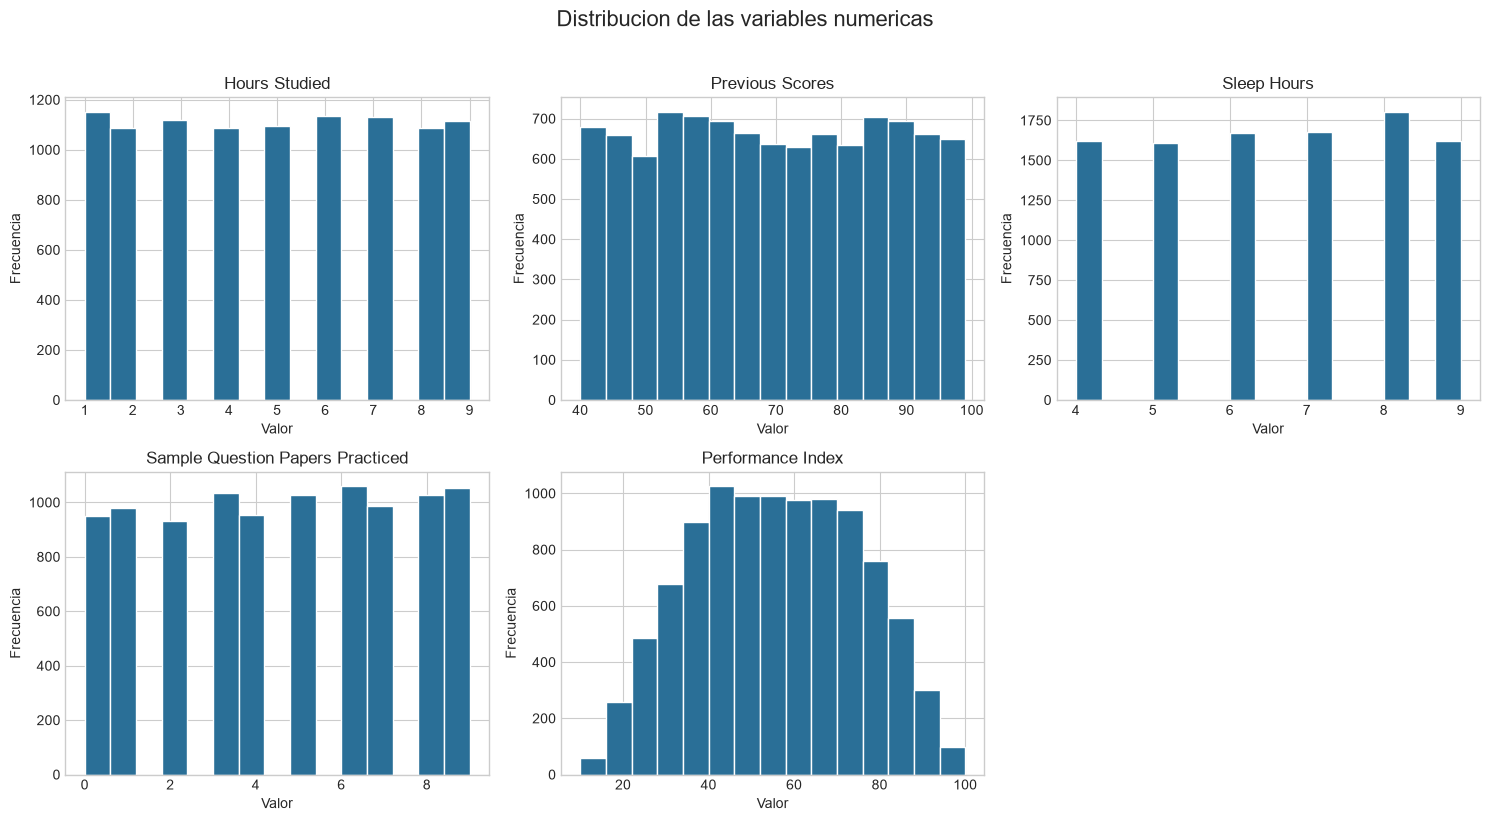

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, columna in zip(axes.flat, variables_numericas):
    ax.hist(df[columna], bins=15, color="#2a6f97", edgecolor="white")
    ax.set_title(columna)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")

axes.flat[-1].set_visible(False)
fig.suptitle("Distribucion de las variables numericas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Boxplots y valores atipicos

Se usa el criterio del rango intercuartil (IQR): un valor es atipico si es menor que `Q1 - 1.5 * IQR` o mayor que `Q3 + 1.5 * IQR`.

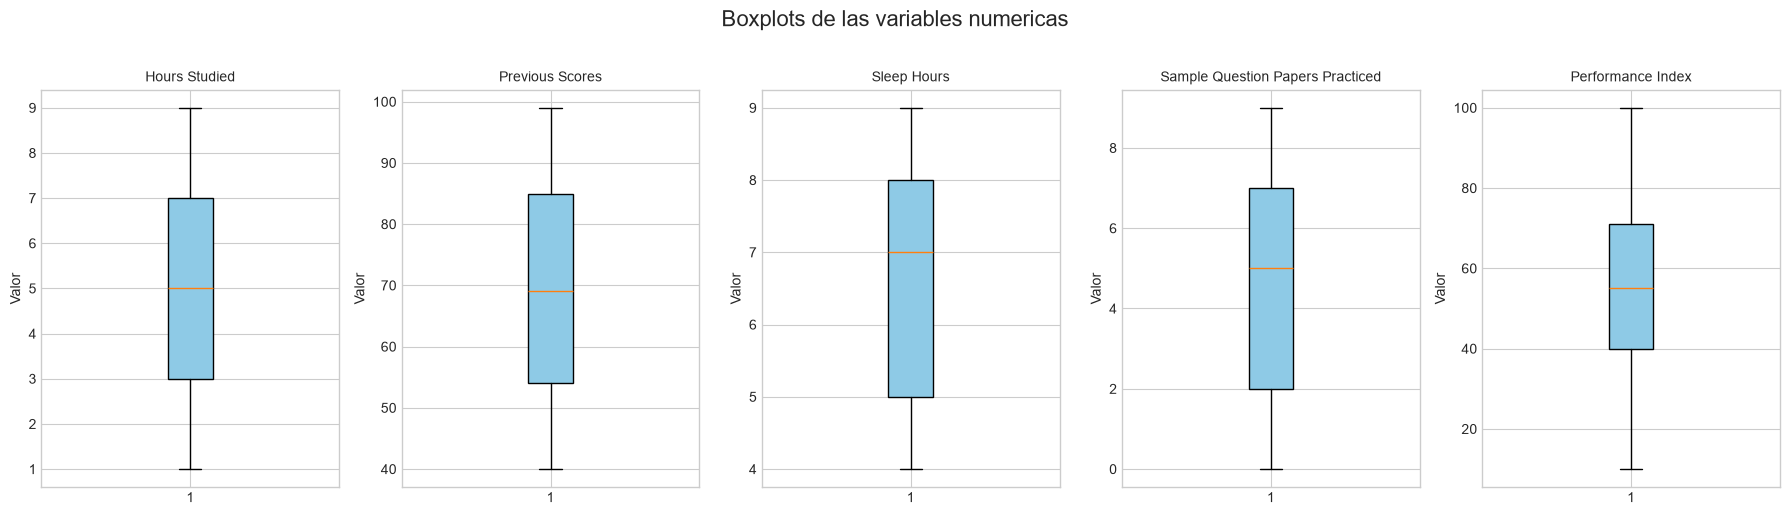

In [10]:
fig, axes = plt.subplots(1, len(variables_numericas), figsize=(18, 5))
for ax, columna in zip(axes, variables_numericas):
    ax.boxplot(df[columna], patch_artist=True, boxprops={"facecolor": "#8ecae6"})
    ax.set_title(columna, fontsize=10)
    ax.set_ylabel("Valor")

fig.suptitle("Boxplots de las variables numericas", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
q1 = df[variables_numericas].quantile(0.25)
q3 = df[variables_numericas].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
mascara_atipicos = df[variables_numericas].lt(limite_inferior) | df[variables_numericas].gt(limite_superior)

reporte_atipicos = pd.DataFrame({
    "Limite inferior": limite_inferior,
    "Limite superior": limite_superior,
    "Cantidad de atipicos": mascara_atipicos.sum(),
    "Porcentaje (%)": (mascara_atipicos.mean() * 100).round(2)
})
reporte_atipicos

,Limite inferior,Limite superior,Cantidad de atipicos,Porcentaje (%)
Hours Studied,-3.0,13.0,0,0.0
Previous Scores,7.5,131.5,0,0.0
Sleep Hours,0.5,12.5,0,0.0
Sample Question Papers Practiced,-5.5,14.5,0,0.0
Performance Index,-6.5,117.5,0,0.0


**Conclusion sobre datos atipicos:** no se identificaron valores atipicos con el criterio IQR en ninguna variable numerica. Los minimos y maximos observados se encuentran dentro de limites plausibles para las escalas del dataset. Por ello, no se eliminan ni se imputan registros; se conserva una copia del dataset original para el analisis posterior.

In [12]:
df_limpio = df.copy()
print(f"Registros antes del tratamiento: {len(df)}")
print(f"Registros despues del tratamiento: {len(df_limpio)}")

Registros antes del tratamiento: 10000
Registros despues del tratamiento: 10000


### Diagramas de dispersion: caracteristicas numericas frente al objetivo

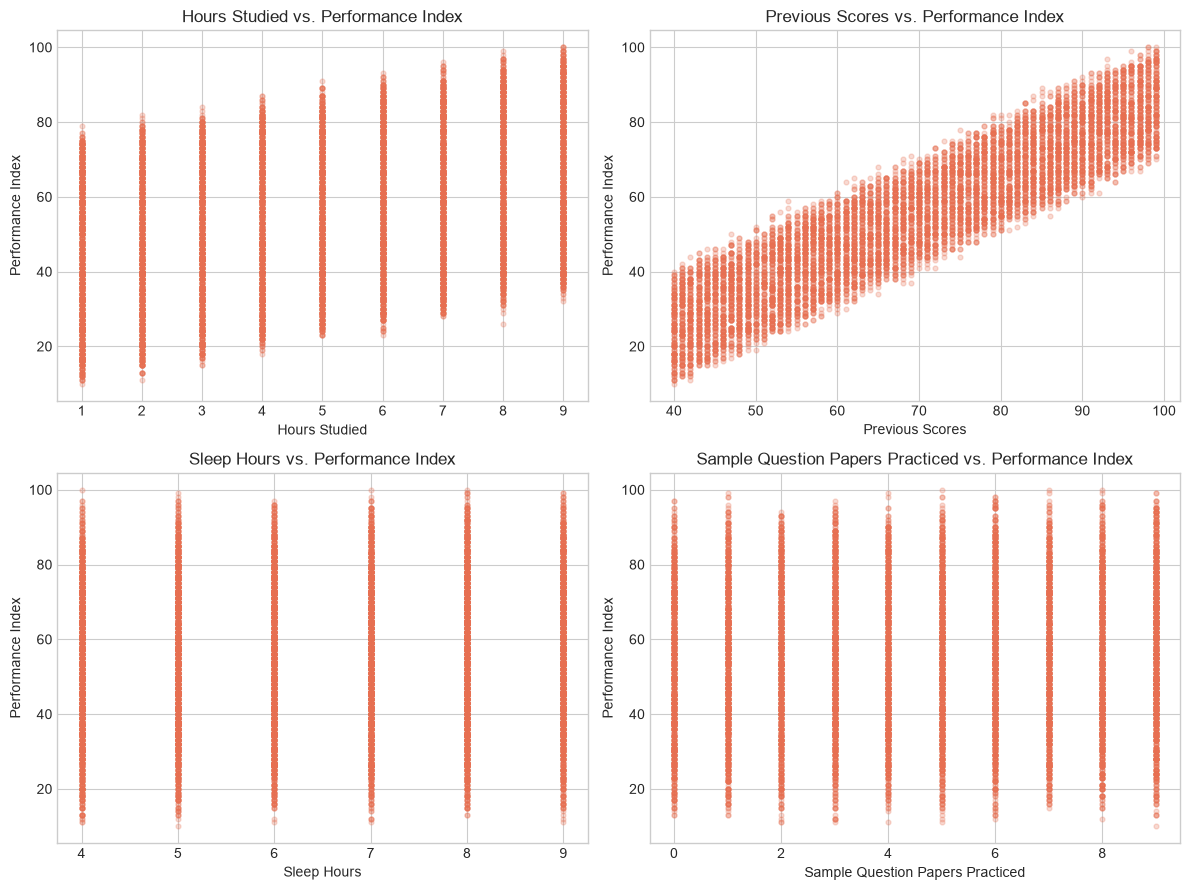

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, columna in zip(axes.flat, caracteristicas_numericas):
    ax.scatter(df_limpio[columna], df_limpio[target], alpha=0.25, s=12, color="#e76f51")
    ax.set_title(f"{columna} vs. {target}")
    ax.set_xlabel(columna)
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

### Actividades extracurriculares y rendimiento

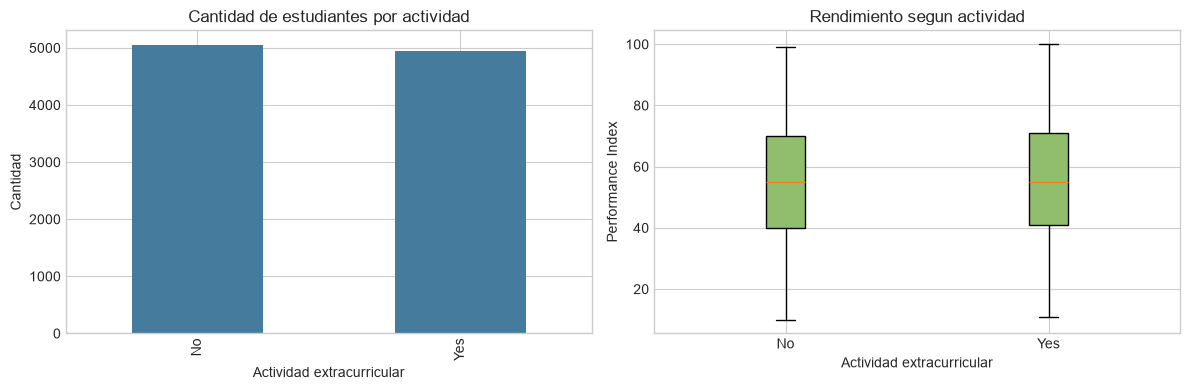

,count,mean,median,std
Extracurricular Activities,,,,
No,5052,54.76,55.0,19.15
Yes,4948,55.70,55.0,19.26


In [14]:
orden_actividad = ["No", "Yes"]
grupos_actividad = [
    df_limpio.loc[df_limpio["Extracurricular Activities"] == categoria, target]
    for categoria in orden_actividad
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_limpio["Extracurricular Activities"].value_counts().reindex(orden_actividad).plot(
    kind="bar", ax=axes[0], color="#457b9d"
)
axes[0].set_title("Cantidad de estudiantes por actividad")
axes[0].set_xlabel("Actividad extracurricular")
axes[0].set_ylabel("Cantidad")

axes[1].boxplot(grupos_actividad, tick_labels=orden_actividad, patch_artist=True, boxprops={"facecolor": "#90be6d"})
axes[1].set_title("Rendimiento segun actividad")
axes[1].set_xlabel("Actividad extracurricular")
axes[1].set_ylabel(target)

plt.tight_layout()
plt.show()

df_limpio.groupby("Extracurricular Activities")[target].agg(["count", "mean", "median", "std"]).round(2)

### Matriz de correlacion y mapa de calor

La correlacion de Pearson permite cuantificar la relacion lineal entre las variables numericas.

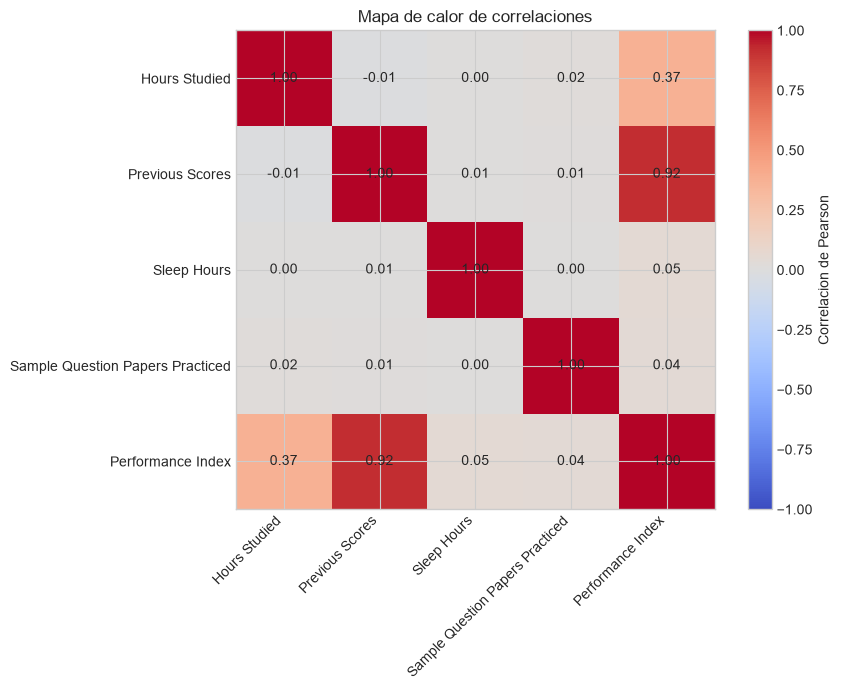

Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64

In [15]:
matriz_correlacion = df_limpio[variables_numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
imagen = ax.imshow(matriz_correlacion, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(variables_numericas)), variables_numericas, rotation=45, ha="right")
ax.set_yticks(range(len(variables_numericas)), variables_numericas)

for fila in range(len(variables_numericas)):
    for columna in range(len(variables_numericas)):
        ax.text(columna, fila, f"{matriz_correlacion.iloc[fila, columna]:.2f}", ha="center", va="center")

fig.colorbar(imagen, ax=ax, label="Correlacion de Pearson")
ax.set_title("Mapa de calor de correlaciones")
plt.tight_layout()
plt.show()

matriz_correlacion[target].sort_values(ascending=False)

### Hallazgos principales

- `Previous Scores` presenta la relacion lineal positiva mas marcada con `Performance Index`, como se observa en el diagrama de dispersion y en la matriz de correlacion.
- `Hours Studied` tambien muestra una asociacion positiva con el rendimiento.
- Las restantes caracteristicas exhiben asociaciones mas moderadas, por lo que pueden aportar informacion complementaria a un modelo de regresion.
- No hay valores faltantes ni valores atipicos segun IQR; el dataset se mantiene sin eliminacion de registros.